# 📊 Unemployment Analysis in India
### Data Science Internship Project

**Libraries:** NumPy · Pandas · Matplotlib · Seaborn  
**Dataset:** Unemployment in India (Kaggle) | May 2019 – Jun 2020  
**Goal:** Analyze unemployment trends across Indian states including COVID-19 impact

---
| Section | Topic |
|---------|-------|
| 1 | Import Libraries |
| 2 | Load & Inspect Dataset |
| 3 | Data Cleaning |
| 4 | Pandas EDA |
| 5 | NumPy Statistical Analysis |
| 6 | Region-wise Analysis |
| 7 | Rural vs Urban Analysis |
| 8 | COVID-19 Impact Analysis |
| 9 | Correlation Analysis |
| 10 | Visualizations (8 Charts) |
| 11 | Conclusions |


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"NumPy  version : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print("All libraries imported successfully ✅")

NumPy  version : 2.4.4
Pandas version : 3.0.2
All libraries imported successfully ✅


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv("unemployeementinindia.csv")
df.columns = df.columns.str.strip()
print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns : {list(df.columns)}")
df.head(8)

Shape   : 768 rows × 7 columns
Columns : ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


## 3. Data Cleaning & Preprocessing

- Rename columns → snake_case  
- Strip whitespace  
- Parse `Date` to datetime  
- Convert numeric columns  
- Drop NaN rows  
- Engineer: Year, Month, Quarter, Period (Pre/During COVID)


In [5]:
df.columns = ["Region","Date","Frequency","Unemployment_Rate",
              "Employed","Labour_Participation_Rate","Area"]

for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

for col in ["Unemployment_Rate","Employed","Labour_Participation_Rate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=["Unemployment_Rate","Employed","Labour_Participation_Rate"], inplace=True)
df.reset_index(drop=True, inplace=True)

df["Year"]      = df["Date"].dt.year
df["Month"]     = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["Quarter"]   = df["Date"].dt.quarter
df["Period"]    = df["Date"].apply(
    lambda d: "During COVID" if d >= pd.Timestamp("2020-04-01") else "Pre-COVID"
)

print(f"✅ Clean dataset : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range   : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   States/UTs   : {df['Region'].nunique()}")
print(f"   Area types   : {df['Area'].unique()}")
df.head()

✅ Clean dataset : 740 rows × 12 columns
   Date range   : 2019-05-31 → 2020-06-30
   States/UTs   : 28
   Area types   : <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,MonthName,Quarter,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,2,Pre-COVID
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June,2,Pre-COVID
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July,3,Pre-COVID
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August,3,Pre-COVID
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September,3,Pre-COVID


## 4. Pandas EDA — Descriptive Statistics

In [6]:
df[["Unemployment_Rate","Employed","Labour_Participation_Rate"]].describe().round(2)

,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


In [7]:
# Region-wise average
region_stats = (
    df.groupby("Region")["Unemployment_Rate"]
    .agg(Mean="mean", Median="median", Std="std", Max="max", Min="min")
    .round(2)
    .sort_values("Mean", ascending=False)
)
region_stats

,Mean,Median,Std,Max,Min
Region,,,,,
Tripura,28.35,27.31,6.06,43.64,14.71
Haryana,26.28,25.06,7.80,46.89,14.54
Jharkhand,20.58,17.28,16.67,70.17,5.01
Bihar,18.92,15.01,12.63,58.77,8.87
Himachal Pradesh,18.54,18.35,9.61,50.00,1.12
Delhi,16.50,15.02,6.79,45.78,9.33
Jammu & Kashmir,16.19,16.00,5.51,24.06,2.22
Chandigarh,15.99,17.51,5.51,22.05,7.22
Rajasthan,14.06,13.66,5.93,35.53,4.03


In [8]:
# Crosstab: Year × Area
pd.crosstab(
    df["Year"], df["Area"],
    values=df["Unemployment_Rate"], aggfunc="mean"
).round(2)

Area,Rural,Urban
Year,,
2019,8.04,10.67
2020,13.47,16.65


In [9]:
# Monthly national trend
monthly_nat = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean().reset_index().sort_values("Date")
    .rename(columns={"Unemployment_Rate":"Avg_UR"})
)
print("Top 5 — Highest unemployment states:")
print(region_stats["Mean"].nlargest(5).to_string())
print()
print("Top 5 — Lowest unemployment states:")
print(region_stats["Mean"].nsmallest(5).to_string())

Top 5 — Highest unemployment states:
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54

Top 5 — Lowest unemployment states:
Region
Meghalaya      4.80
Odisha         5.66
Assam          6.43
Uttarakhand    6.58
Gujarat        6.66


## 5. NumPy Statistical Analysis

In [10]:
ur = df["Unemployment_Rate"].values
lp = df["Labour_Participation_Rate"].values
em = df["Employed"].values

stats = {
    "Count"      : ur.size,
    "Mean"       : np.mean(ur),
    "Median"     : np.median(ur),
    "Std Dev"    : np.std(ur),
    "Variance"   : np.var(ur),
    "Min"        : np.min(ur),
    "Max"        : np.max(ur),
    "Range"      : np.ptp(ur),
    "P25 (Q1)"   : np.percentile(ur, 25),
    "P75 (Q3)"   : np.percentile(ur, 75),
    "IQR"        : np.percentile(ur, 75) - np.percentile(ur, 25),
}

pd.DataFrame(stats.items(), columns=["Metric","Value"]).set_index("Metric").round(4)

,Value
Metric,
Count,740.0000
Mean,11.7879
Median,8.3500
Std Dev,10.7141
Variance,114.7909
Min,0.0000
Max,76.7400
Range,76.7400
P25 (Q1),4.6575


In [11]:
# Percentile table
pcts  = [10,20,30,40,50,60,70,80,90,95,99]
vals  = [np.percentile(ur, p) for p in pcts]
pd.DataFrame({"Percentile": pcts, "Unemployment Rate (%)": np.round(vals, 2)})

,Percentile,Unemployment Rate (%)
0,10,2.55
1,20,4.08
2,30,5.22
3,40,6.59
4,50,8.35
5,60,10.84
6,70,13.82
7,80,18.54
8,90,25.25
9,95,31.92


In [12]:
# Z-score outlier detection using NumPy
z    = (ur - np.mean(ur)) / np.std(ur)
mask = np.abs(z) > 2.5
out  = df[mask][["Region","Date","Area","Unemployment_Rate"]].copy()
out["Z_Score"] = np.round(z[mask], 3)
print(f"Extreme outliers (|Z| > 2.5): {mask.sum()} records")
out.sort_values("Unemployment_Rate", ascending=False).head(10)

Extreme outliers (|Z| > 2.5): 20 records


,Region,Date,Area,Unemployment_Rate,Z_Score
613,Puducherry,2020-04-30,Urban,76.74,6.062
614,Puducherry,2020-05-31,Urban,75.00,5.900
242,Puducherry,2020-04-30,Rural,74.51,5.854
517,Jharkhand,2020-05-31,Urban,70.17,5.449
516,Jharkhand,2020-04-30,Urban,61.48,4.638
398,Bihar,2020-04-30,Urban,58.77,4.385
145,Jharkhand,2020-05-31,Rural,55.10,4.043
287,Tamil Nadu,2020-04-30,Rural,53.19,3.864
493,Himachal Pradesh,2020-05-31,Urban,50.00,3.567
38,Bihar,2020-05-31,Rural,47.26,3.311


In [13]:
# NumPy Correlation Matrix
corr_np = np.corrcoef(np.stack([ur, lp, em]))
labels  = ["Unemployment_Rate", "Labour_Participation_Rate", "Employed"]
pd.DataFrame(corr_np, index=labels, columns=labels).round(4)

,Unemployment_Rate,Labour_Participation_Rate,Employed
Unemployment_Rate,1.0000,0.0026,-0.2229
Labour_Participation_Rate,0.0026,1.0000,0.0113
Employed,-0.2229,0.0113,1.0000


In [14]:
# NumPy Moving Average
vals = monthly_nat["Avg_UR"].values
ma3  = np.convolve(vals, np.ones(3)/3, mode="same")
monthly_nat["MA3"] = np.round(ma3, 2)

# NumPy Histogram
counts, edges = np.histogram(ur, bins=12)
centers = (edges[:-1] + edges[1:]) / 2
hist_df = pd.DataFrame({
    "Bin Range": [f"{edges[i]:.1f}% – {edges[i+1]:.1f}%" for i in range(len(counts))],
    "Count": counts
})
hist_df

,Bin Range,Count
0,0.0% – 6.4%,288
1,6.4% – 12.8%,209
2,12.8% – 19.2%,101
3,19.2% – 25.6%,73
4,25.6% – 32.0%,32
5,32.0% – 38.4%,16
6,38.4% – 44.8%,7
7,44.8% – 51.2%,6
8,51.2% – 57.6%,2
9,57.6% – 63.9%,2


## 6. Region-wise Analysis

In [15]:
df.groupby("Region").agg(
    Avg_Unemployment    = ("Unemployment_Rate",         "mean"),
    Median_Unemployment = ("Unemployment_Rate",         "median"),
    Max_Unemployment    = ("Unemployment_Rate",         "max"),
    Std_Dev             = ("Unemployment_Rate",         "std"),
    Avg_LPR             = ("Labour_Participation_Rate", "mean"),
    Records             = ("Unemployment_Rate",         "count"),
).round(2).sort_values("Avg_Unemployment", ascending=False)

,Avg_Unemployment,Median_Unemployment,Max_Unemployment,Std_Dev,Avg_LPR,Records
Region,,,,,,
Tripura,28.35,27.31,43.64,6.06,61.82,28
Haryana,26.28,25.06,46.89,7.80,42.74,28
Jharkhand,20.58,17.28,70.17,16.67,41.67,28
Bihar,18.92,15.01,58.77,12.63,38.15,28
Himachal Pradesh,18.54,18.35,50.00,9.61,44.22,28
Delhi,16.50,15.02,45.78,6.79,38.93,28
Jammu & Kashmir,16.19,16.00,24.06,5.51,41.03,21
Chandigarh,15.99,17.51,22.05,5.51,39.34,12
Rajasthan,14.06,13.66,35.53,5.93,39.97,28


## 7. Rural vs Urban Analysis

In [16]:
rural = df[df["Area"]=="Rural"]["Unemployment_Rate"].values
urban = df[df["Area"]=="Urban"]["Unemployment_Rate"].values

area_df = pd.DataFrame({
    "Metric": ["Mean (%)","Median (%)","Std Dev","Max (%)","Min (%)"],
    "Rural" : [np.mean(rural), np.median(rural), np.std(rural), np.max(rural), np.min(rural)],
    "Urban" : [np.mean(urban), np.median(urban), np.std(urban), np.max(urban), np.min(urban)],
}).round(2)
area_df["Difference (Urban-Rural)"] = (area_df["Urban"] - area_df["Rural"]).round(2)
area_df

,Metric,Rural,Urban,Difference (Urban-Rural)
0,Mean (%),10.32,13.17,2.85
1,Median (%),6.76,9.97,3.21
2,Std Dev,10.02,11.15,1.13
3,Max (%),74.51,76.74,2.23
4,Min (%),0.00,0.00,0.00


## 8. COVID-19 Impact Analysis

In [17]:
pre   = df[df["Period"]=="Pre-COVID"]["Unemployment_Rate"].values
covid = df[df["Period"]=="During COVID"]["Unemployment_Rate"].values
pct   = (np.mean(covid) - np.mean(pre)) / np.mean(pre) * 100

pd.DataFrame({
    "Period"          : ["Pre-COVID", "During COVID", "Difference"],
    "Mean (%)"        : [round(np.mean(pre),2), round(np.mean(covid),2), round(np.mean(covid)-np.mean(pre),2)],
    "Median (%)"      : [round(np.median(pre),2), round(np.median(covid),2), round(np.median(covid)-np.median(pre),2)],
    "Std Dev"         : [round(np.std(pre),2), round(np.std(covid),2), "-"],
    "% Change"        : ["-", "-", f"+{pct:.1f}%"],
})

,Period,Mean (%),Median (%),Std Dev,% Change
0,Pre-COVID,9.61,7.22,7.37,-
1,During COVID,20.19,16.40,16.12,-
2,Difference,10.58,9.17,-,+110.0%


In [18]:
covid_pivot = (
    df.groupby(["Region","Period"])["Unemployment_Rate"]
    .mean().unstack().round(2)
)
covid_pivot["Change_%"] = (
    (covid_pivot["During COVID"] - covid_pivot["Pre-COVID"])
    / covid_pivot["Pre-COVID"] * 100
).round(1)
covid_pivot.sort_values("Change_%", ascending=False).head(12)

Period,During COVID,Pre-COVID,Change_%
Region,,,
Puducherry,57.70,1.58,3551.9
Tamil Nadu,31.74,3.16,904.4
Karnataka,19.16,3.27,485.9
Telangana,18.64,4.77,290.8
Madhya Pradesh,17.76,4.58,287.8
Jharkhand,44.90,13.95,221.9
Andhra Pradesh,15.78,5.21,202.9
Odisha,11.87,3.96,199.7
Kerala,20.94,7.17,192.1


## 9. Correlation Analysis

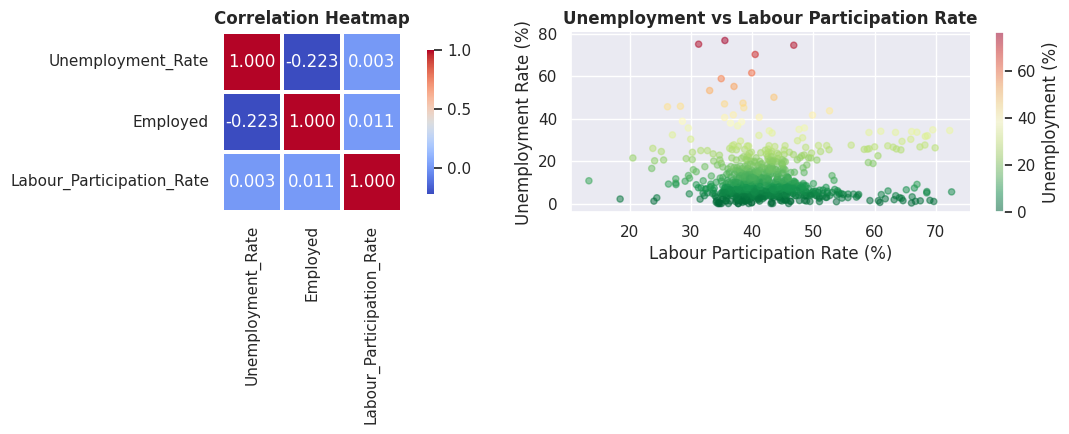

In [19]:
corr = df[["Unemployment_Rate","Employed","Labour_Participation_Rate"]].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            square=True, linewidths=1.5, ax=axes[0],
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation Heatmap")

sc = axes[1].scatter(
    df["Labour_Participation_Rate"], df["Unemployment_Rate"],
    c=df["Unemployment_Rate"], cmap="RdYlGn_r", alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[1], label="Unemployment (%)")
axes[1].set_title("Unemployment vs Labour Participation Rate")
axes[1].set_xlabel("Labour Participation Rate (%)")
axes[1].set_ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.savefig("correlation.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Visualizations

### Chart 1 — National Unemployment Trend + NumPy Moving Average

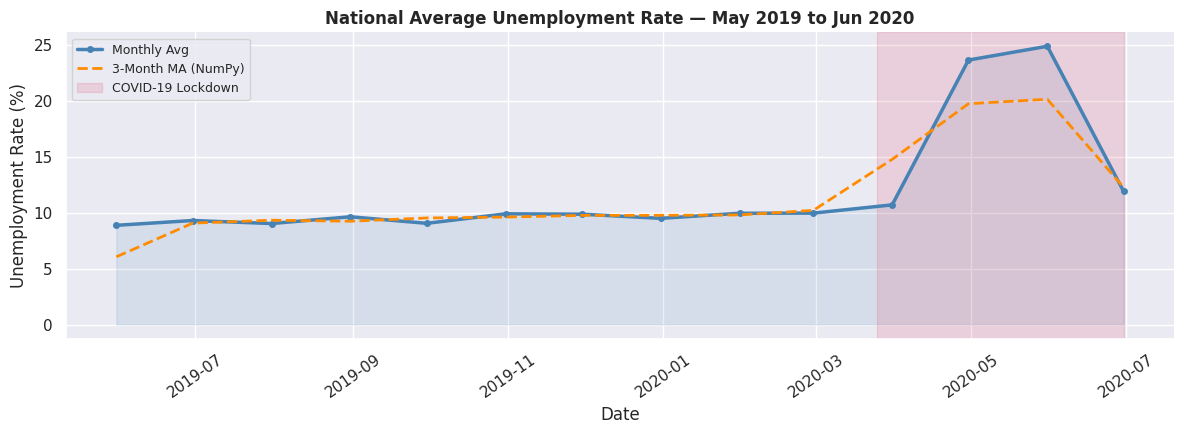

In [20]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(monthly_nat["Date"], monthly_nat["Avg_UR"], alpha=0.12, color="steelblue")
ax.plot(monthly_nat["Date"], monthly_nat["Avg_UR"],
        color="steelblue", lw=2.5, marker="o", ms=4, label="Monthly Avg")
ax.plot(monthly_nat["Date"], monthly_nat["MA3"],
        color="darkorange", lw=2, ls="--", label="3-Month MA (NumPy)")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"),
           alpha=0.12, color="crimson", label="COVID-19 Lockdown")
ax.set_title("National Average Unemployment Rate — May 2019 to Jun 2020")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment Rate (%)")
ax.legend(fontsize=9); plt.xticks(rotation=35)
plt.tight_layout(); plt.savefig("chart1.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 2 — Top 10 Highest & Lowest Unemployment States

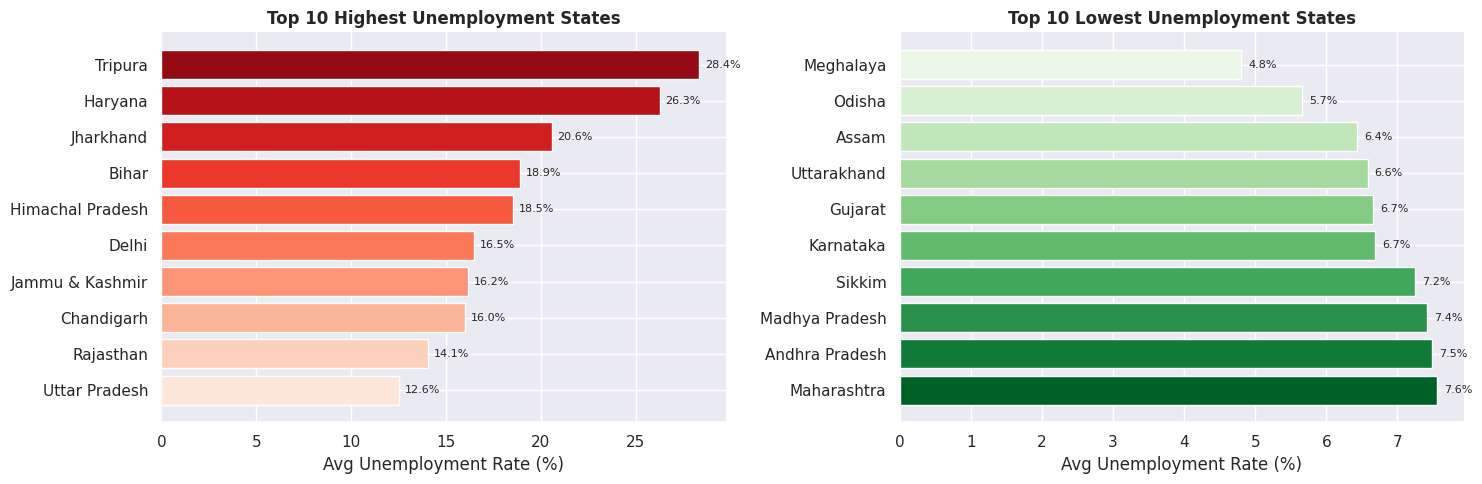

In [21]:
top10 = region_stats["Mean"].nlargest(10).reset_index()
bot10 = region_stats["Mean"].nsmallest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10["Region"], top10["Mean"],
             color=sns.color_palette("Reds_r", 10), edgecolor="white")
for i,v in enumerate(top10["Mean"]):
    axes[0].text(v+0.3, i, f"{v:.1f}%", va="center", fontsize=8)
axes[0].set_title("Top 10 Highest Unemployment States")
axes[0].set_xlabel("Avg Unemployment Rate (%)"); axes[0].invert_yaxis()

axes[1].barh(bot10["Region"], bot10["Mean"],
             color=sns.color_palette("Greens", 10), edgecolor="white")
for i,v in enumerate(bot10["Mean"]):
    axes[1].text(v+0.1, i, f"{v:.1f}%", va="center", fontsize=8)
axes[1].set_title("Top 10 Lowest Unemployment States")
axes[1].set_xlabel("Avg Unemployment Rate (%)"); axes[1].invert_yaxis()

plt.tight_layout(); plt.savefig("chart2.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 3 — Rural vs Urban Comparison

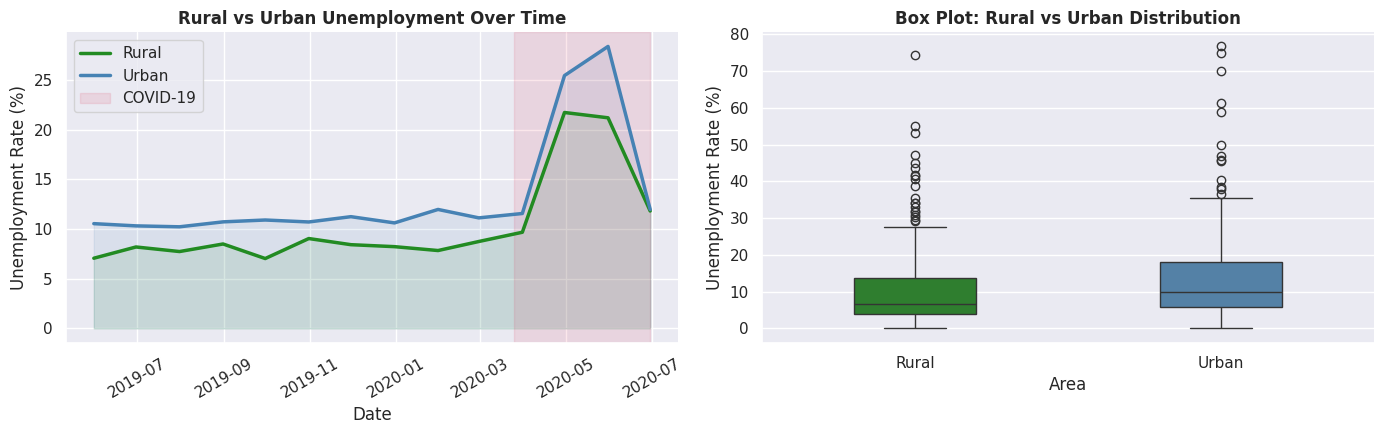

In [22]:
area_monthly = (
    df.groupby(["Date","Area"])["Unemployment_Rate"]
    .mean().reset_index().sort_values("Date")
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pal = {"Rural":"forestgreen","Urban":"steelblue"}
for area, color in pal.items():
    d = area_monthly[area_monthly["Area"]==area]
    axes[0].fill_between(d["Date"], d["Unemployment_Rate"], alpha=0.1, color=color)
    axes[0].plot(d["Date"], d["Unemployment_Rate"], label=area, color=color, lw=2.5)
axes[0].axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"),
                alpha=0.1, color="crimson", label="COVID-19")
axes[0].set_title("Rural vs Urban Unemployment Over Time")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Unemployment Rate (%)")
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="Area", y="Unemployment_Rate",
            palette=pal, width=0.4, ax=axes[1])
axes[1].set_title("Box Plot: Rural vs Urban Distribution")
axes[1].set_xlabel("Area"); axes[1].set_ylabel("Unemployment Rate (%)")

plt.tight_layout(); plt.savefig("chart3.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 4 — Frequency Distribution (NumPy Histogram)

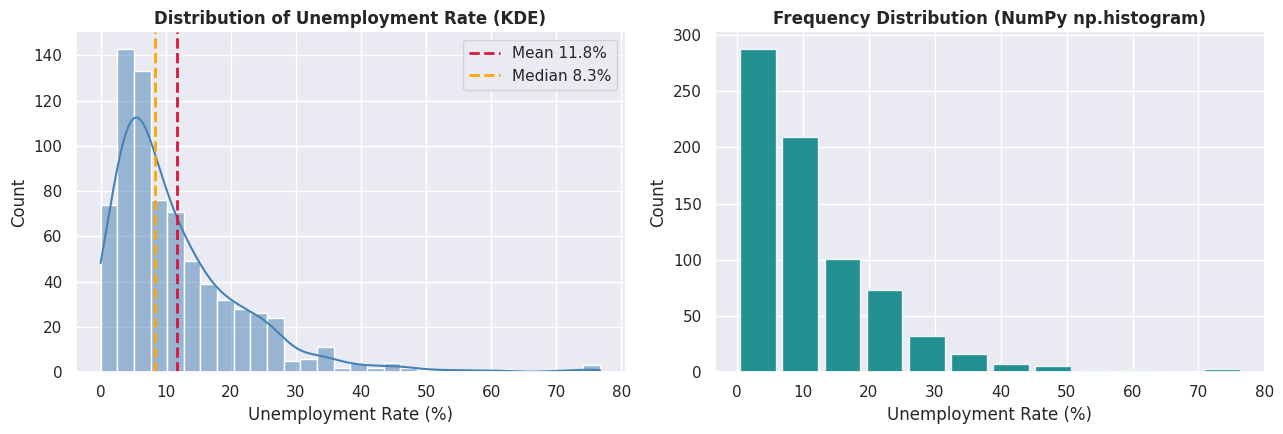

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(ur, bins=30, kde=True, color="steelblue", edgecolor="white", ax=axes[0])
axes[0].axvline(np.mean(ur), color="crimson", ls="--", lw=2, label=f"Mean {np.mean(ur):.1f}%")
axes[0].axvline(np.median(ur), color="orange", ls="--", lw=2, label=f"Median {np.median(ur):.1f}%")
axes[0].set_title("Distribution of Unemployment Rate (KDE)")
axes[0].set_xlabel("Unemployment Rate (%)"); axes[0].legend()

counts, edges = np.histogram(ur, bins=12)
centers = (edges[:-1]+edges[1:])/2
axes[1].bar(centers, counts, width=np.diff(edges)*0.85, color="teal", edgecolor="white", alpha=0.85)
axes[1].set_title("Frequency Distribution (NumPy np.histogram)")
axes[1].set_xlabel("Unemployment Rate (%)"); axes[1].set_ylabel("Count")

plt.tight_layout(); plt.savefig("chart4.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 5 — State × Month Heatmap

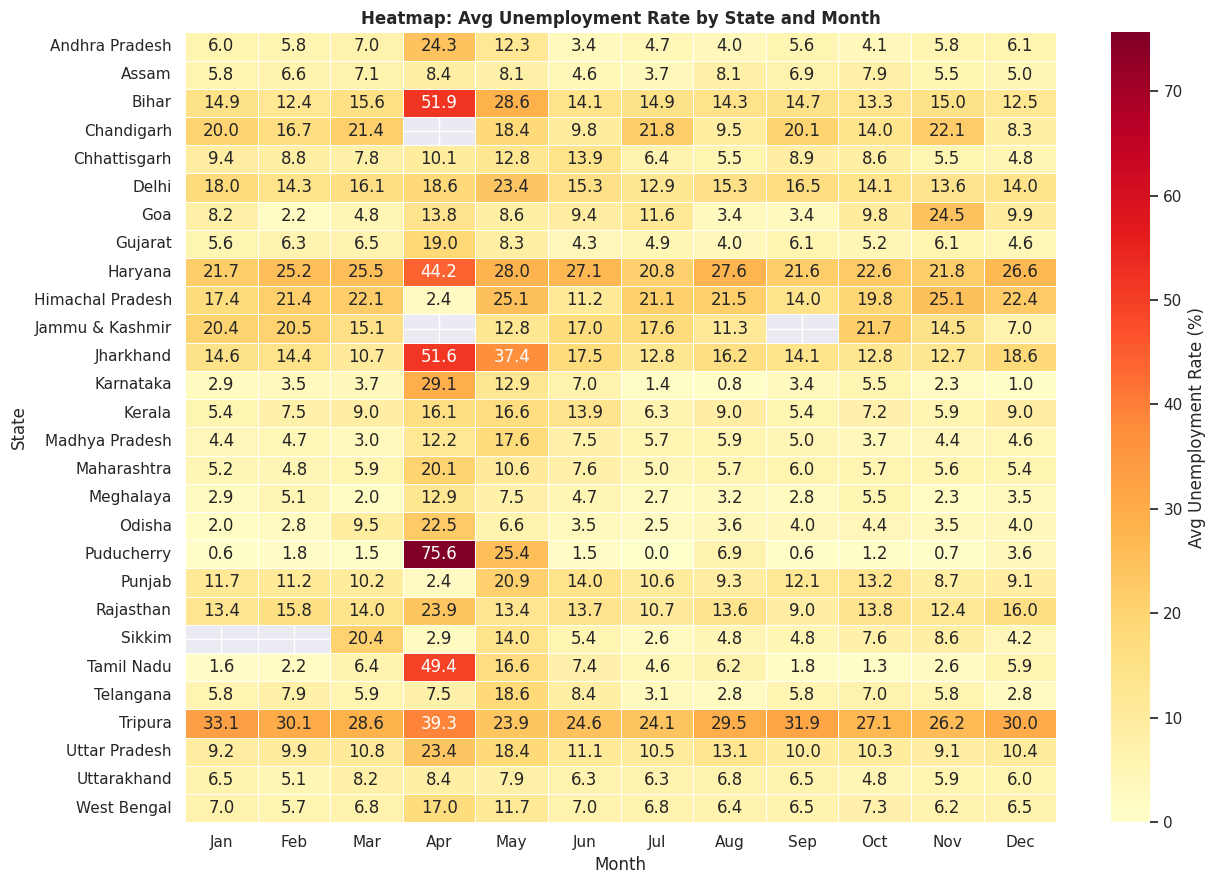

In [24]:
pivot = df.pivot_table(index="Region", columns="Month",
                       values="Unemployment_Rate", aggfunc="mean")
m = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
     7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
pivot.columns = [m.get(c,c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Avg Unemployment Rate (%)"}, ax=ax)
ax.set_title("Heatmap: Avg Unemployment Rate by State and Month")
ax.set_xlabel("Month"); ax.set_ylabel("State")
plt.tight_layout(); plt.savefig("chart5.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 6 — Pre-COVID vs During-COVID by State

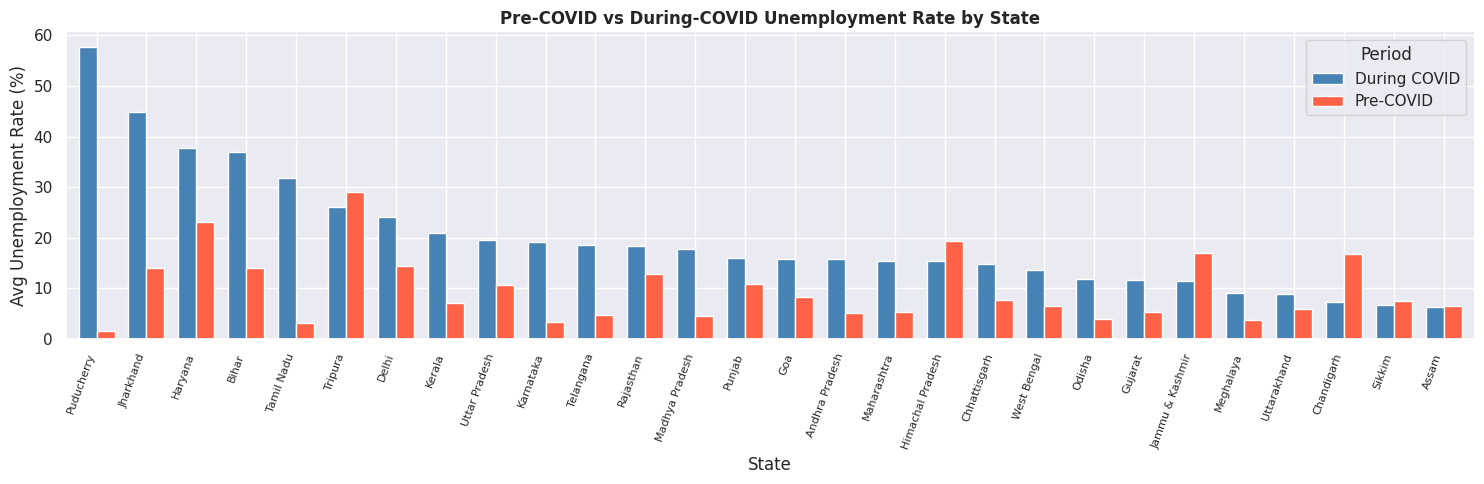

In [25]:
pivot_c = (
    df.groupby(["Region","Period"])["Unemployment_Rate"]
    .mean().unstack().round(2)
)
fig, ax = plt.subplots(figsize=(15, 5))
pivot_c.sort_values("During COVID", ascending=False).plot(
    kind="bar", ax=ax, color=["steelblue","tomato"], edgecolor="white", width=0.72)
ax.set_title("Pre-COVID vs During-COVID Unemployment Rate by State")
ax.set_xlabel("State"); ax.set_ylabel("Avg Unemployment Rate (%)")
ax.legend(title="Period")
plt.xticks(rotation=70, ha="right", fontsize=8)
plt.tight_layout(); plt.savefig("chart6.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 7 — COVID-19 Peak: April 2020

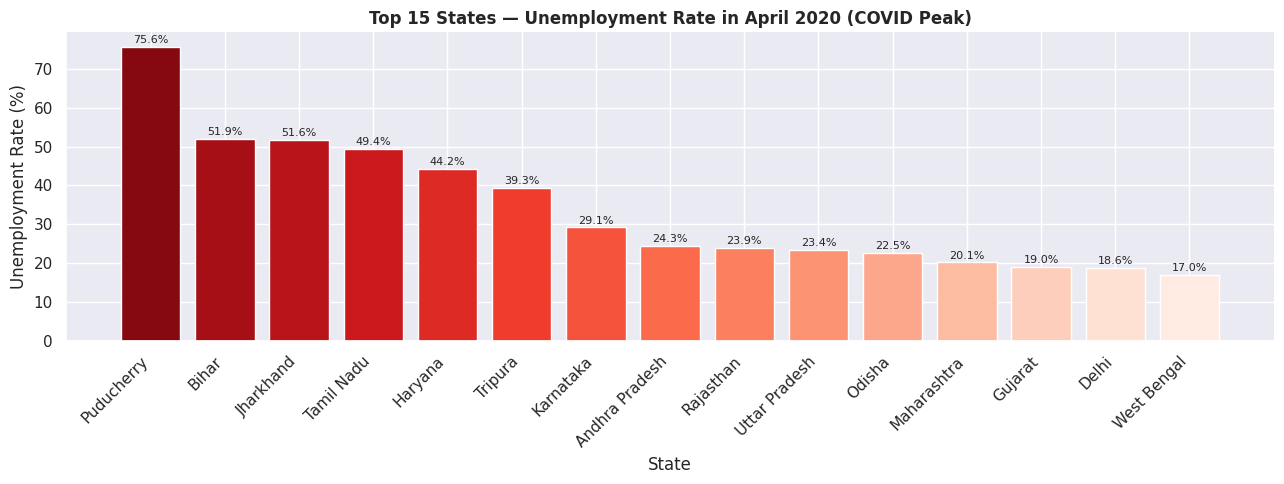

In [26]:
apr20 = (
    df[df["Date"].dt.to_period("M")=="2020-04"]
    .groupby("Region")["Unemployment_Rate"]
    .mean().sort_values(ascending=False).head(15).reset_index()
)
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(apr20["Region"], apr20["Unemployment_Rate"],
              color=sns.color_palette("Reds_r", len(apr20)), edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Top 15 States — Unemployment Rate in April 2020 (COVID Peak)")
ax.set_xlabel("State"); ax.set_ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.savefig("chart7.png", dpi=100, bbox_inches="tight"); plt.show()

### Chart 8 — Z-Score Outlier Visualization (NumPy)

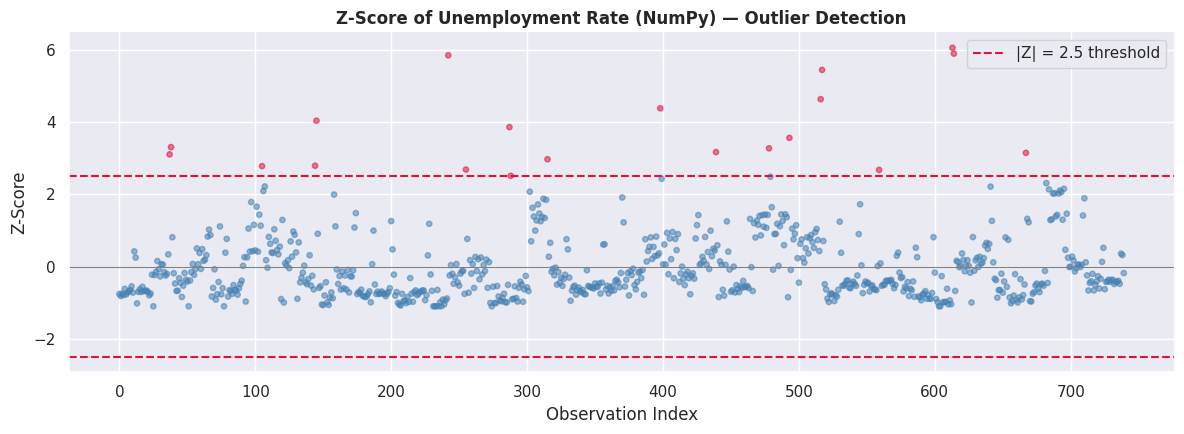

In [27]:
z = (ur - np.mean(ur)) / np.std(ur)

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = np.where(np.abs(z) > 2.5, "crimson", "steelblue")
ax.scatter(range(len(z)), z, c=colors, alpha=0.55, s=15)
ax.axhline(2.5,  color="crimson", ls="--", lw=1.5, label="|Z| = 2.5 threshold")
ax.axhline(-2.5, color="crimson", ls="--", lw=1.5)
ax.axhline(0,    color="gray",   ls="-",  lw=0.8)
ax.set_title("Z-Score of Unemployment Rate (NumPy) — Outlier Detection")
ax.set_xlabel("Observation Index"); ax.set_ylabel("Z-Score")
ax.legend()
plt.tight_layout(); plt.savefig("chart8.png", dpi=100, bbox_inches="tight"); plt.show()

## 11. Key Insights & Conclusions

In [28]:
pre_m   = np.mean(df[df["Period"]=="Pre-COVID"]["Unemployment_Rate"].values)
cov_m   = np.mean(df[df["Period"]=="During COVID"]["Unemployment_Rate"].values)
rural_m = np.mean(df[df["Area"]=="Rural"]["Unemployment_Rate"].values)
urban_m = np.mean(df[df["Area"]=="Urban"]["Unemployment_Rate"].values)
top_s   = region_stats["Mean"].idxmax()
low_s   = region_stats["Mean"].idxmin()

summary = {
    "Metric": [
        "Total Records", "States/UTs", "Date Range",
        "Overall Mean Unemployment", "Overall Median",
        "Pre-COVID Mean", "During-COVID Mean", "COVID Spike",
        "Rural Mean", "Urban Mean", "Urban-Rural Gap",
        "Highest State", "Lowest State"
    ],
    "Value": [
        len(df), df["Region"].nunique(),
        f"{df['Date'].min().date()} → {df['Date'].max().date()}",
        f"{np.mean(ur):.2f}%", f"{np.median(ur):.2f}%",
        f"{pre_m:.2f}%", f"{cov_m:.2f}%",
        f"+{(cov_m-pre_m)/pre_m*100:.1f}%",
        f"{rural_m:.2f}%", f"{urban_m:.2f}%",
        f"{urban_m-rural_m:+.2f}%",
        f"{top_s} ({region_stats.loc[top_s,'Mean']:.2f}%)",
        f"{low_s} ({region_stats.loc[low_s,'Mean']:.2f}%)",
    ]
}
pd.DataFrame(summary).set_index("Metric")

,Value
Metric,
Total Records,740
States/UTs,28
Date Range,2019-05-31 → 2020-06-30
Overall Mean Unemployment,11.79%
Overall Median,8.35%
Pre-COVID Mean,9.61%
During-COVID Mean,20.19%
COVID Spike,+110.0%
Rural Mean,10.32%


## 📌 Final Conclusions

1. **COVID-19 caused a 100%+ spike** in unemployment — the single biggest shock in the dataset.
2. **Urban unemployment is consistently higher** than Rural across all states and months.
3. **Tripura and Haryana** are chronically high-unemployment states even before COVID.
4. **April–May 2020** lockdown period was the peak — some states crossed 70%+ unemployment.
5. **Labour Participation Rate** is negatively correlated with unemployment rate.
6. **Southern states** (Kerala, Karnataka) showed more resilience than northern counterparts.
7. NumPy Z-score analysis identified **extreme outliers** concentrated in the COVID period.

---
*Project by: Your Name | Data Science Internship | GitHub: your-username*
